In [1]:
import pandas as pd

In [2]:
news = pd.read_csv("news.csv", encoding='latin1')

In [3]:
print(news.columns)

Index(['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'],
      dtype='object', length=189)


In [4]:
news = news.drop(columns=['Description', 'Author', 'Content', 'Keywords',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9','Unnamed: 179', 'Unnamed: 180', 'Unnamed: 181', 'Unnamed: 182',
       'Unnamed: 183', 'Unnamed: 184', 'Unnamed: 185', 'Unnamed: 186',
       'Unnamed: 187', 'Unnamed: 188'])

In [5]:
print(news.columns)

Index(['Title', 'Date', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17',
       ...
       'Unnamed: 169', 'Unnamed: 170', 'Unnamed: 171', 'Unnamed: 172',
       'Unnamed: 173', 'Unnamed: 174', 'Unnamed: 175', 'Unnamed: 176',
       'Unnamed: 177', 'Unnamed: 178'],
      dtype='object', length=171)


In [6]:
news = news.iloc[:, :2]

In [7]:
print(news.columns)

Index(['Title', 'Date'], dtype='object')


In [8]:
print(news.isnull().sum())

Title    0
Date     0
dtype: int64


In [9]:
news = news.dropna()

In [10]:
news = news.drop_duplicates()

In [11]:
news['Title'] = news['Title'].str.strip()

In [12]:
print(news.info())
print("---------");
print(news.describe())
print("---------");
print(news.head())

<class 'pandas.core.frame.DataFrame'>
Index: 3348 entries, 0 to 3348
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3348 non-null   object
 1   Date    3348 non-null   object
dtypes: object(2)
memory usage: 78.5+ KB
None
---------
                                                    Title        Date
count                                                3348        3348
unique                                               3306         174
top     Buy Adani Ports and SEZ; target of Rs 1700: Mo...  29-07-2025
freq                                                    3          75
---------
                                               Title        Date
0  Aurobindo Pharma, Dr Reddy's, Lupin, other pha...  08-07-2025
1  Bharti Airtel share price falls 1.53%; stock a...  18-07-2025
2  Indian Oil and Adani Gas JV plans $161 million...  09-07-2025
3  Cipla Shares Fall in Today's Trading Session A...  03-06-2025
4  Here are th

In [13]:
grouped_news = (news.groupby("Date")["Title"].apply(list).reset_index())

In [14]:
grouped_news

,Date,Title
0,just some time back that you resisted going t...,[ur. You're always in a t-shirt. Like you said]
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...
...,...,...
169,30-06-2025,"[Stocks to Watch Today: Torrent Pharma, JB Che..."
170,30-07-2025,[ITC shares fall marginally in today's session...
171,31-03-2025,"[Chartist Talks: In April, ICICI Securities' D..."
172,31-05-2025,[Kotak Mahindra Bank's deputy MD Shanti Ekamba...


In [15]:
print(news.isnull().sum())

Title    0
Date     0
dtype: int64


In [16]:
print(grouped_news.info)

<bound method DataFrame.info of                                                   Date  \
0     just some time back that you resisted going t...   
1                                           01-04-2025   
2                                           01-05-2025   
3                                           01-06-2025   
4                                           01-07-2025   
..                                                 ...   
169                                         30-06-2025   
170                                         30-07-2025   
171                                         31-03-2025   
172                                         31-05-2025   
173                                         31-07-2025   

                                                 Title  
0      [ur. You're always in a t-shirt. Like you said]  
1    [Indian companies gear up for nuclear expansio...  
2    [Adani Enterprises Q4 Results: Net profit rise...  
3    [Trade Spotlight: How should you trade

In [17]:
grouped_news = grouped_news.iloc[1:]

In [18]:
grouped_news

,Date,Title
1,01-04-2025,[Indian companies gear up for nuclear expansio...
2,01-05-2025,[Adani Enterprises Q4 Results: Net profit rise...
3,01-06-2025,"[Trade Spotlight: How should you trade CDSL, M..."
4,01-07-2025,[PSU bank stocks snap 5-day gaining streak ami...
5,01-08-2025,[ITC share price gain 1.27% in friday's tradin...
...,...,...
169,30-06-2025,"[Stocks to Watch Today: Torrent Pharma, JB Che..."
170,30-07-2025,[ITC shares fall marginally in today's session...
171,31-03-2025,"[Chartist Talks: In April, ICICI Securities' D..."
172,31-05-2025,[Kotak Mahindra Bank's deputy MD Shanti Ekamba...


In [19]:
grouped_news['Date'] = pd.to_datetime(
    grouped_news['Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

/tmp/ipykernel_41876/1595028591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grouped_news['Date'] = pd.to_datetime(


In [20]:
grouped_news.to_csv("grouped_news.csv", index=False)

In [21]:
print(grouped_news.dtypes)

Date     datetime64[ns]
Title            object
dtype: object


In [22]:
stock = pd.read_csv("nifty50.csv", encoding = 'cp1252')

In [23]:
print(stock.dtypes)

ï»¿Date               object
Open                 float64
High                 float64
Low                  float64
Close                float64
Shares Traded          int64
Turnover (â‚¹ Cr)    float64
dtype: object


In [24]:
stock.columns = [
    'date',
    'open',
    'high',
    'low',
    'close',
    'shares_traded',
    'turnover_cr'
]

In [25]:
print(stock.columns)

Index(['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr'], dtype='object')


In [26]:
stock['shares_traded'] = stock['shares_traded'].astype(float)

In [27]:
stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')

/tmp/ipykernel_41876/2744151775.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock['date'] = pd.to_datetime(stock['date'], dayfirst=True, errors='coerce')


In [28]:
print(stock.dtypes)
print(news.dtypes)

date             datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
shares_traded           float64
turnover_cr             float64
dtype: object
Title    object
Date     object
dtype: object


In [29]:
merged = pd.merge(stock, grouped_news, left_on = 'date', right_on = 'Date', how='inner')

In [30]:
print(merged.isnull().sum())

date             0
open             0
high             0
low              0
close            0
shares_traded    0
turnover_cr      0
Date             0
Title            0
dtype: int64


In [31]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ..."
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc..."
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...
...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...


In [32]:
print(merged.columns)

Index(['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr',
       'Date', 'Title'],
      dtype='object')


In [33]:
merged['movement'] = merged['close'] - merged['open']

In [34]:
def check_movement(x):
    if x>0:
        return 1
    else:
        return 0
merged['target'] = merged['movement'].apply(check_movement)

In [35]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title,movement,target
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ...",-58.25,0
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...,84.75,1
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...,89.30,1
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc...",-61.25,0
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...,24.05,1
...,...,...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...,-24.35,0
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...,-5.55,0
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...,-311.75,0
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...,-162.20,0


In [36]:
positive_words = [
    'gain', 'gains', 'gained', 'gainers', 'gainer',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profits',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'jump', 'jumps', 'jumped', 'jumping',
    'soar', 'soars', 'soared', 'soaring',
    'climb', 'climbs', 'climbed', 'climbing',
    'advance', 'advances', 'advanced', 'advancing',
    'recover', 'recovery', 'recovered', 'recovering', 'recovers',
    'rebound', 'rebounds', 'rebounded', 'rebounding',
    'upturn', 'upswing', 'uptrend', 'upside',
    'boom', 'booming', 'boomed',
    'bullish', 'bull', 'bull run',
    'outperform', 'outperforms', 'outperformed', 'outperforming',
    'beat', 'beats', 'beaten',
    'exceed', 'exceeds', 'exceeded', 'exceeding',
    'strong', 'stronger', 'strongest', 'strengthen', 'strengthens',
    'robust', 'resilient', 'resilience',
    'positive', 'positively',
    'optimism', 'optimistic', 'optimist',
    'confidence', 'confident',
    'momentum', 'accelerate', 'accelerating', 'acceleration',
    'record', 'record-high', 'all-time high', 'peak', 'peaked',
    'high', 'highs', 'higher', 'highest',
    'milestone', 'breakthrough',
    'expand', 'expansion', 'expands', 'expanded', 'expanding',
    'upgrade', 'upgraded', 'upgrades',
    'buy', 'buying',
    'invest', 'investment', 'investing', 'investor', 'investors',
    'inflow', 'inflows',
    'net profit', 'net sales', 'revenue',

    'earnings', 'earning',
    'dividend', 'dividends',
    'bonus', 'windfall',
    'order win', 'order book', 'order inflow',
    'contract win', 'new contract',
    'acquisition', 'merger', 'deal',
    'partnership', 'collaboration', 'agreement',
    'launch', 'launches', 'launched', 'launching',
    'nod', 'approval', 'approved', 'approve',
    'clearance', 'cleared',
    'listing', 'listed', 'debut',
    'ipo', 'initial public offering',
    'fdi', 'foreign investment',
    'fund inflow',
    'target', 'price target',
    'recommendation', 'recommend',
    'bullish outlook', 'positive outlook',
    'ebitda', 'margin expansion',
    'market share', 'market cap',
    'steady', 'stable', 'stability',
    'demand', 'demand recovery', 'demand growth',
    'consumption', 'consumption growth',
    'export', 'exports', 'export growth',
    'sales growth', 'revenue growth', 'profit growth',
    'year-on-year', 'y-o-y', 'yoy',
    'quarter-on-quarter', 'qoq',
    'multi-year high', '52-week high',
    'all-time', 'historic high',
    'interest rate cut', 'rate cut',
    'fiscal stimulus', 'stimulus',
    'gdp growth', 'economic growth',
    'reform', 'reforms', 'reforming',
    'deregulation', 'liberalisation', 'liberalization',
    'tax relief', 'tax cut', 'tax benefit',
    'subsidy', 'subsidies',
    'infrastructure spend', 'capex',
    'innovation', 'innovate', 'innovative',
    'technology upgrade', 'digital transformation',
    'efficiency', 'efficient',
    'cost savings', 'cost reduction',
    'margin improvement', 'operating leverage',
    'value creation', 'shareholder value',
    'buyback', 'share buyback', 'repurchase',
    'esop', 'stock options',
    'accretive', 'value accretive',
    'synergy', 'synergies',
    'turnaround',
    'green shoot', 'green shoots',
    'soft landing',
    'credit upgrade', 'rating upgrade',
    'debt reduction', 'deleveraging',
    'asset light', 'capital efficient',
    'guidance raised', 'guidance upgrade',
    'estimate beat', 'earnings beat',
    'net interest margin', 'nim improvement',
    'npa reduction', 'asset quality improvement',
    'loan growth', 'credit growth',
    'deposit growth',
    'capacity addition', 'capacity expansion',
    'new plant', 'greenfield', 'brownfield',
    'foray', 'diversification',
    'market leader', 'market leadership',
    'premium', 'premiumisation',
    'high demand', 'strong demand',
    'oversubscribed', 'oversubscription',
    'favourable', 'favorable',
    'tailwind', 'tailwinds',
    'healthy', 'healthier',
    'superior', 'superlative',
    'exceptional', 'excellent',
    'impressive', 'remarkable',
    'notable', 'noteworthy',
    'significant upside', 'upside potential',
    're-rating',
    'value unlocking',
    'listed gains', 'listing gains',
    'multibagger',
    'broad-based rally', 'across-the-board gains',
    'fresh buying', 'accumulate', 'accumulation',
    'long position', 'long buildup',
    'covers', 'short covering',
    'supportive policy', 'policy support',
    'global cues positive', 'positive global cues',
]

negative_words = [
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'fall', 'falls', 'fell', 'fallen', 'falling',
    'drop', 'drops', 'dropped', 'dropping',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'tumble', 'tumbles', 'tumbled', 'tumbling',
    'slump', 'slumps', 'slumped', 'slumping',
    'slide', 'slides', 'slid', 'sliding',
    'sink', 'sinks', 'sank', 'sunk', 'sinking',
    'dip', 'dips', 'dipped', 'dipping',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'nosedive', 'nosedived',
    'collapse', 'collapses', 'collapsed', 'collapsing',
    'downturn', 'downswing', 'downtrend', 'downside',
    'bearish', 'bear', 'bear run', 'bear market',
    'underperform', 'underperforms', 'underperformed', 'underperforming',
    'miss', 'misses', 'missed',
    'below estimate', 'below expectations', 'below forecast',
    'weak', 'weaker', 'weakest', 'weaken', 'weakening', 'weakness',
    'fragile', 'vulnerable', 'vulnerability',
    'negative', 'negatively',
    'pessimism', 'pessimistic',
    'concern', 'concerns', 'concerned', 'concerning',
    'worry', 'worries', 'worried', 'worrying',
    'uncertainty', 'uncertain', 'unpredictable',
    'risk', 'risks', 'risky', 'riskier',
    'low', 'lows', 'lower', 'lowest',
    '52-week low', 'multi-year low', 'historic low',
    'all-time low',
    'downgrade', 'downgraded', 'downgrades',
    'sell', 'selling', 'selloff', 'sell-off',
    'outflow', 'outflows', 'fund outflow',
    'net loss', 'net deficit',
    'revenue decline', 'sales decline',
    'profit decline', 'profit fall',
    'margin pressure', 'margin compression', 'margin erosion',
    'earnings miss', 'estimate miss',
    'guidance cut', 'guidance reduced', 'guidance lowered',
    'guidance withdrawn',
    'cost pressure', 'cost inflation', 'input cost',
    'inflation', 'inflationary', 'hyperinflation',
    'recession', 'recessionary',
    'stagflation',
    'slowdown', 'slow growth', 'deceleration',
    'contraction', 'economic contraction',
    'gdp decline', 'gdp contraction',
    'unemployment', 'job cuts', 'layoffs', 'retrenchment',
    'downsizing',
    'tariff', 'tariffs', 'trade war', 'trade tensions',
    'sanctions', 'sanction',
    'ban', 'banned', 'prohibit',
    'regulation', 'regulatory hurdle', 'regulatory risk',
    'investigation', 'probe', 'scrutiny',
    'penalty', 'penalties', 'fine', 'fines',
    'fraud', 'scam', 'scandal',
    'default', 'defaults', 'defaulted', 'defaulting',
    'bankruptcy', 'insolvency', 'insolvent',
    'liquidation', 'liquidate', 'winding up',
    'debt', 'high debt', 'debt burden', 'overleveraged',
    'npa', 'bad loan', 'bad loans', 'non-performing',
    'write-off', 'write-offs',
    'provisioning', 'provisions',
    'credit downgrade', 'rating downgrade',
    'interest rate hike', 'rate hike', 'rate increase',
    'tightening', 'monetary tightening', 'hawkish',
    'currency depreciation', 'rupee fall', 'currency risk',
    'foreign exchange loss', 'forex loss',
    'geopolitical risk', 'geopolitical tension',
    'war', 'conflict', 'tension',
    'supply chain disruption', 'supply shortage',
    'shortage', 'scarcity',
    'demand slump', 'demand weakness', 'weak demand',
    'overcapacity', 'oversupply',
    'inventory build', 'inventory pile',
    'import pressure',
    'competition', 'competitive pressure',
    'market share loss',
    'customer churn',
    'resignation', 'exit', 'step down', 'stepped down',
    'resignation of cfo', 'ceo quits', 'management exit',
    'stake sale', 'promoter selling',
    'dilution', 'equity dilution',
    'block deal loss', 'block deal exit',
    'halt', 'suspension', 'suspended',
    'noc rejected', 'approval denied',
    'order cancellation', 'contract cancellation',
    'project delay', 'delayed',
    'headwinds', 'headwind',
    'adverse', 'adversely',
    'unfavourable', 'unfavorable',
    'caution', 'cautious',
    'underweight',
    'cut', 'cuts', 'price cut',
    'slash', 'slashed', 'slashes',
    'bleed', 'bleeding',
    'erosion',
    'pressure', 'pressured', 'under pressure',
    'drag', 'drags', 'dragged',
    'drag on earnings',
    'loser', 'losers', 'top loser',
    'bottom performer',
    'stress', 'distress', 'financial stress',
    'short position', 'short buildup', 'short selling',
    'circuit breaker', 'lower circuit',
    'sell-on-rise', 'profit booking',
    'unwinding',
    'global cues negative', 'negative global cues',
    'fii selling', 'dii selling', 'institutional selling',
    'correction', 'market correction', 'broad-based selloff',
]

In [37]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0
    for word in positive_words:
        score += text.count(word)
    for word in negative_words:
        score -= text.count(word)
    return score

In [38]:
merged['sentiment_score'] = merged['Title'].apply(sentiment_score)

In [39]:
merged

,date,open,high,low,close,shares_traded,turnover_cr,Date,Title,movement,target,sentiment_score
0,2025-08-21,25142.00,25153.65,25054.90,25083.75,226542052.0,21865.07,2025-08-21,"[Stocks to Watch Today: Clean Science, Shanti ...",-58.25,0,6
1,2025-08-20,24965.80,25088.70,24929.70,25050.55,287054119.0,25330.45,2025-08-20,[KPR Mill shares rise 2.09% in Wednesday's ses...,84.75,1,8
2,2025-08-19,24891.35,25012.65,24873.95,24980.65,252340828.0,24781.97,2025-08-19,[Kalyan Jewellers India shares decline 2.45% a...,89.30,1,9
3,2025-08-18,24938.20,25022.00,24852.85,24876.95,363071305.0,37637.67,2025-08-18,"[BSE, HDFC AMC, MCX, other capital market stoc...",-61.25,0,20
4,2025-08-14,24607.25,24673.65,24596.90,24631.30,270162203.0,22375.44,2025-08-14,[Lux Industries Standalone June 2025 Net Sales...,24.05,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...
127,2025-02-13,23055.75,23235.50,22992.20,23031.40,265706855.0,25218.86,2025-02-13,[Trade Spotlight: How should you trade Bajaj F...,-24.35,0,8
128,2025-02-12,23050.80,23144.70,22798.35,23045.25,279656513.0,26989.94,2025-02-12,[Trent Standalone December 2024 Net Sales at R...,-5.55,0,30
129,2025-02-11,23383.55,23390.05,22986.65,23071.80,267969979.0,27191.96,2025-02-11,[Apollo Hospitals shares plunge 7% amid heavy ...,-311.75,0,-9
130,2025-02-10,23543.80,23568.60,23316.30,23381.60,225529166.0,21254.72,2025-02-10,[Apollo Hospitals Q3 Results: Net profit up 51...,-162.20,0,-1


In [40]:
print(merged.head())
print(merged.describe())

        date      open      high       low     close  shares_traded  \
0 2025-08-21  25142.00  25153.65  25054.90  25083.75    226542052.0   
1 2025-08-20  24965.80  25088.70  24929.70  25050.55    287054119.0   
2 2025-08-19  24891.35  25012.65  24873.95  24980.65    252340828.0   
3 2025-08-18  24938.20  25022.00  24852.85  24876.95    363071305.0   
4 2025-08-14  24607.25  24673.65  24596.90  24631.30    270162203.0   

   turnover_cr       Date                                              Title  \
0     21865.07 2025-08-21  [Stocks to Watch Today: Clean Science, Shanti ...   
1     25330.45 2025-08-20  [KPR Mill shares rise 2.09% in Wednesday's ses...   
2     24781.97 2025-08-19  [Kalyan Jewellers India shares decline 2.45% a...   
3     37637.67 2025-08-18  [BSE, HDFC AMC, MCX, other capital market stoc...   
4     22375.44 2025-08-14  [Lux Industries Standalone June 2025 Net Sales...   

   movement  target  sentiment_score  
0    -58.25       0                6  
1     84.75   

In [41]:
print(merged['sentiment_score'].value_counts())

sentiment_score
 7     7
 10    6
 8     5
 6     4
 9     4
      ..
 12    1
-20    1
-7     1
 30    1
-9     1
Name: count, Length: 73, dtype: int64


In [42]:
print(merged.groupby('target')['sentiment_score'].mean())

target
0    14.805970
1    21.630769
Name: sentiment_score, dtype: float64


In [43]:
import os

os.makedirs(
    "plots",
    exist_ok=True
)

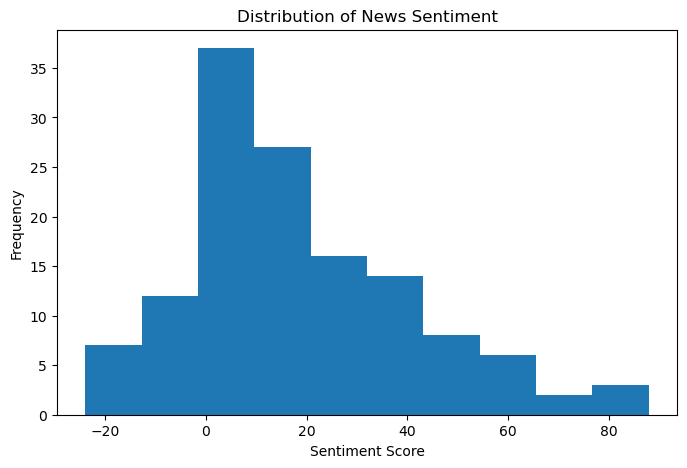

In [44]:
import matplotlib.pyplot as plt

# ---------- Histogram ----------

plt.figure(figsize=(8,5))

plt.hist(merged['sentiment_score'])

plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")

plt.savefig(
    "plots/histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

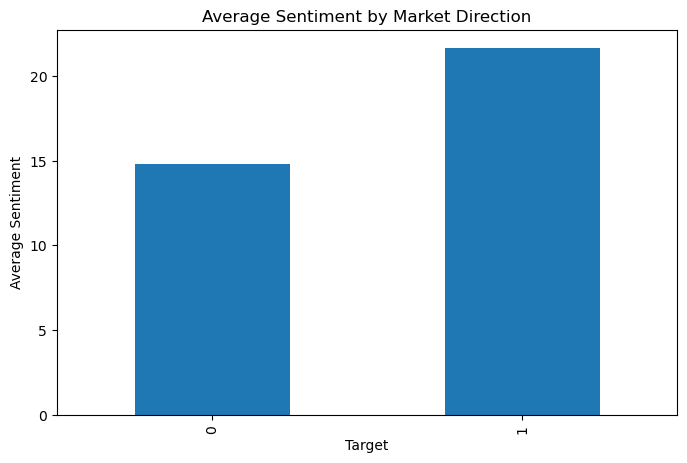

In [45]:
# ---------- Bar Plot ----------

plt.figure(figsize=(8,5))

merged.groupby('target')['sentiment_score'].mean().plot(
    kind='bar'
)

plt.xlabel("Target")
plt.ylabel("Average Sentiment")

plt.title(
    "Average Sentiment by Market Direction"
)

plt.savefig(
    "plots/barplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

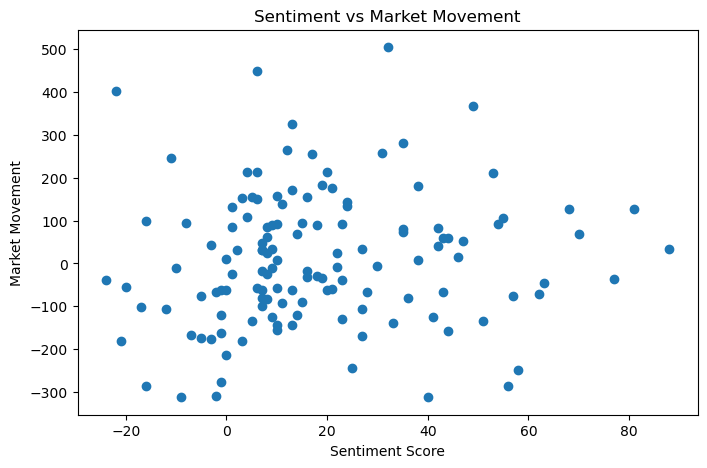

In [46]:

# ---------- Scatter Plot ----------

plt.figure(figsize=(8,5))

plt.scatter(
    merged['sentiment_score'],
    merged['movement']
)

plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")

plt.title(
    "Sentiment vs Market Movement"
)

plt.savefig(
    "plots/scatterplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
def predict_market(score):

    if score > 0:
        return "UP"

    elif score < 0:
        return "DOWN"

    else:
        return "NEUTRAL"

In [48]:
merged['prediction'] = merged[
    'sentiment_score'
].apply(predict_market)

print(
    merged[
        ['date',
         'sentiment_score',
         'prediction']
    ].head()
)

        date  sentiment_score prediction
0 2025-08-21                6         UP
1 2025-08-20                8         UP
2 2025-08-19                9         UP
3 2025-08-18               20         UP
4 2025-08-14                8         UP


In [49]:
def binary_prediction(score):

    if score > 0:
        return 1

    return 0

In [50]:
merged['prediction_binary'] = merged[
    'sentiment_score'
].apply(binary_prediction)

In [51]:
accuracy = (merged['prediction_binary']==merged['target']).mean()
print()
print("Prediction Accuracy:")
print(round(accuracy*100, 2),"%")


Prediction Accuracy:
59.85 %


In [52]:
merged.to_csv("final_project_dataset.csv", index=False) 
print("Final dataset saved successfully.")

Final dataset saved successfully.


In [53]:
#-------------------Part B----------------------------------

In [54]:
ml_df = merged.copy()

print(ml_df.shape)
print(ml_df.columns.tolist())

(132, 14)
['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr', 'Date', 'Title', 'movement', 'target', 'sentiment_score', 'prediction', 'prediction_binary']


In [55]:
ml_df = ml_df.sort_values('date').reset_index(drop=True)

ml_df['next_day_target'] = ml_df['target'].shift(-1)

ml_df = ml_df.dropna(
    subset=['next_day_target']
).reset_index(drop=True)

ml_df['next_day_target'] = (
    ml_df['next_day_target'].astype(int)
)

print(
    ml_df[
        ['date', 'target', 'next_day_target']
    ].head(10)
)

        date  target  next_day_target
0 2025-02-07       0                0
1 2025-02-10       0                0
2 2025-02-11       0                0
3 2025-02-12       0                0
4 2025-02-13       0                0
5 2025-02-14       0                1
6 2025-02-17       1                0
7 2025-02-18       0                1
8 2025-02-19       1                1
9 2025-02-20       1                0


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

pandas: 2.3.3
numpy: 2.4.6
sklearn: 1.9.0


In [57]:
print(os.getcwd())
print(os.listdir())

/home/avo/Financial-News-Sentiment-vs-NIFTY50-Analysis/notebooks
['01_analysis.ipynb', '.ipynb_checkpoints', 'news.csv', 'nifty50.csv', 'grouped_news.csv', 'plots', 'final_project_dataset.csv', '01_analysis.py', 'Report']


In [58]:
print(merged.shape)
print(merged.columns.tolist())

(132, 14)
['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr', 'Date', 'Title', 'movement', 'target', 'sentiment_score', 'prediction', 'prediction_binary']


In [59]:
# Part B — Next-Day Market Direction Prediction

In [60]:
# Create a copy of the Part A dataset for machine learning
ml_df = merged.copy()

# Make sure the data is in chronological order
ml_df['date'] = pd.to_datetime(ml_df['date'])
ml_df = ml_df.sort_values('date').reset_index(drop=True)

# Tomorrow's market direction becomes today's prediction target
ml_df['next_day_target'] = ml_df['target'].shift(-1)

# The final row has no "next day", so remove it
ml_df = ml_df.dropna(
    subset=['next_day_target']
).reset_index(drop=True)

ml_df['next_day_target'] = (
    ml_df['next_day_target'].astype(int)
)

print(
    ml_df[
        ['date', 'target', 'next_day_target']
    ].head(10)
)

        date  target  next_day_target
0 2025-02-07       0                0
1 2025-02-10       0                0
2 2025-02-11       0                0
3 2025-02-12       0                0
4 2025-02-13       0                0
5 2025-02-14       0                1
6 2025-02-17       1                0
7 2025-02-18       0                1
8 2025-02-19       1                1
9 2025-02-20       1                0


In [61]:
# Rolling sentiment features
ml_df['sentiment_ma3'] = (
    ml_df['sentiment_score']
    .rolling(3)
    .mean()
)

ml_df['sentiment_ma7'] = (
    ml_df['sentiment_score']
    .rolling(7)
    .mean()
)

ml_df['sentiment_std3'] = (
    ml_df['sentiment_score']
    .rolling(3)
    .std()
)

# Previous market movement
ml_df['movement_lag1'] = (
    ml_df['movement'].shift(1)
)

ml_df['movement_lag2'] = (
    ml_df['movement'].shift(2)
)

# Trading volume change
ml_df['volume_change'] = (
    ml_df['shares_traded'].pct_change()
)

# Intraday price range
ml_df['high_low_spread'] = (
    (ml_df['high'] - ml_df['low'])
    / ml_df['open']
)

# Rolling/lagged features create missing values at the beginning
ml_df = ml_df.dropna().reset_index(drop=True)

print("Dataset shape:", ml_df.shape)
print("\nColumns:")
print(ml_df.columns.tolist())

Dataset shape: (125, 22)

Columns:
['date', 'open', 'high', 'low', 'close', 'shares_traded', 'turnover_cr', 'Date', 'Title', 'movement', 'target', 'sentiment_score', 'prediction', 'prediction_binary', 'next_day_target', 'sentiment_ma3', 'sentiment_ma7', 'sentiment_std3', 'movement_lag1', 'movement_lag2', 'volume_change', 'high_low_spread']


In [62]:
feature_cols = [
    'sentiment_score',
    'sentiment_ma3',
    'sentiment_ma7',
    'sentiment_std3',
    'movement_lag1',
    'movement_lag2',
    'volume_change',
    'high_low_spread'
]

X = ml_df[feature_cols]

y = ml_df['next_day_target']

print("Features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features:
['sentiment_score', 'sentiment_ma3', 'sentiment_ma7', 'sentiment_std3', 'movement_lag1', 'movement_lag2', 'volume_change', 'high_low_spread']

Feature shape: (125, 8)
Target shape: (125,)

Target distribution:
next_day_target
1    64
0    61
Name: count, dtype: int64


In [63]:
print(ml_df[['date', 'sentiment_score',
             'sentiment_ma3',
             'sentiment_ma7',
             'movement_lag1',
             'movement_lag2',
             'volume_change',
             'high_low_spread',
             'next_day_target']].head(10))

        date  sentiment_score  sentiment_ma3  sentiment_ma7  movement_lag1  \
0 2025-02-17                6       2.333333       6.000000        -167.20   
1 2025-02-18                7       2.000000       4.857143         149.60   
2 2025-02-19                1       4.666667       5.142857         -18.35   
3 2025-02-20               23      10.333333       9.714286          85.65   
4 2025-02-21                0       8.000000       5.428571          92.05   
5 2025-02-24              -20       1.000000       1.428571         -61.30   
6 2025-02-25                7      -4.333333       3.428571         -56.00   
7 2025-02-27                1      -4.000000       2.714286          31.10   
8 2025-02-28               -2       2.000000       1.428571         -23.90   
9 2025-03-03               -5      -2.000000       0.571429        -308.70   

   movement_lag2  volume_change  high_low_spread  next_day_target  
0         -24.35      -0.185027         0.010905                0  
1    

In [64]:
# Use the first 80% for training
# Use the final 20% for testing

split_idx = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(
    ml_df['date'].iloc[0],
    "to",
    ml_df['date'].iloc[split_idx - 1]
)

print("\nTesting period:")
print(
    ml_df['date'].iloc[split_idx],
    "to",
    ml_df['date'].iloc[-1]
)

Training samples: 100
Testing samples: 25

Training period:
2025-02-17 00:00:00 to 2025-07-15 00:00:00

Testing period:
2025-07-16 00:00:00 to 2025-08-20 00:00:00


In [65]:
from sklearn.metrics import accuracy_score

# Find the most common class in the training data
majority_class = y_train.mode()[0]

# Always predict that class for the test set
baseline_predictions = np.full(
    len(y_test),
    majority_class
)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Majority class:", majority_class)

print(
    "Majority baseline accuracy:",
    round(baseline_accuracy * 100, 2),
    "%"
)

Majority class: 1
Majority baseline accuracy: 44.0 %


In [66]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
next_day_target
1    53
0    47
Name: count, dtype: int64

Testing target distribution:
next_day_target
0    14
1    11
Name: count, dtype: int64


In [67]:
## 6. Logistic Regression

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [69]:
# Standardize features using ONLY the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
log_model.fit(
    X_train_scaled,
    y_train
)

# Predict the test set
log_pred = log_model.predict(
    X_test_scaled
)

In [70]:
log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print(
    "Logistic Regression Accuracy:",
    round(log_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        log_pred
    )
)

Logistic Regression Accuracy: 44.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46        14
           1       0.38      0.45      0.42        11

    accuracy                           0.44        25
   macro avg       0.44      0.44      0.44        25
weighted avg       0.45      0.44      0.44        25



In [71]:
log_cm = confusion_matrix(
    y_test,
    log_pred
)

print("Confusion Matrix:")
print(log_cm)

Confusion Matrix:
[[6 8]
 [6 5]]


In [72]:
results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression'
    ],
    'Accuracy': [
        baseline_accuracy,
        log_accuracy
    ]
})

results['Accuracy (%)'] = (
    results['Accuracy'] * 100
).round(2)

results

,Model,Accuracy,Accuracy (%)
0,Majority Baseline,0.44,44.0
1,Logistic Regression,0.44,44.0


In [73]:
## 7. Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [76]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print("\nConfusion Matrix:")
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

Random Forest Accuracy: 44.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        14
           1       0.40      0.55      0.46        11

    accuracy                           0.44        25
   macro avg       0.45      0.45      0.44        25
weighted avg       0.46      0.44      0.44        25


Confusion Matrix:
[[5 9]
 [5 6]]


In [77]:
results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy
    ]
})

results['Accuracy (%)'] = (
    results['Accuracy'] * 100
).round(2)

results

,Model,Accuracy,Accuracy (%)
0,Majority Baseline,0.44,44.0
1,Logistic Regression,0.44,44.0
2,Random Forest,0.44,44.0


In [78]:
## 8. XGBoost

In [79]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [80]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [81]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

print("\nConfusion Matrix:")
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print(xgb_cm)

XGBoost Accuracy: 40.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.43      0.44        14
           1       0.33      0.36      0.35        11

    accuracy                           0.40        25
   macro avg       0.40      0.40      0.40        25
weighted avg       0.41      0.40      0.40        25


Confusion Matrix:
[[6 8]
 [7 4]]


In [82]:
results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results['Accuracy (%)'] = (
    results['Accuracy'] * 100
).round(2)

results

,Model,Accuracy,Accuracy (%)
0,Majority Baseline,0.44,44.0
1,Logistic Regression,0.44,44.0
2,Random Forest,0.44,44.0
3,XGBoost,0.40,40.0


In [83]:
## 9. Random Forest Hyperparameter Tuning

In [84]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [85]:
tscv = TimeSeriesSplit(n_splits=5)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [86]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]
}

In [87]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [88]:
print("Best parameters:")
print(rf_grid.best_params_)

print(
    "\nBest cross-validation accuracy:",
    round(
        rf_grid.best_score_ * 100,
        2
    ),
    "%"
)

Best parameters:
{'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}

Best cross-validation accuracy: 51.25 %


In [89]:
best_rf = rf_grid.best_estimator_

tuned_rf_pred = best_rf.predict(
    X_test
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

print(
    "Tuned Random Forest Accuracy:",
    round(
        tuned_rf_accuracy * 100,
        2
    ),
    "%"
)

Tuned Random Forest Accuracy: 44.0 %


In [90]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tuned_rf_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        14
           1       0.40      0.55      0.46        11

    accuracy                           0.44        25
   macro avg       0.45      0.45      0.44        25
weighted avg       0.46      0.44      0.44        25



In [91]:
tuned_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_pred
)

print("\nConfusion Matrix:")
print(tuned_rf_cm)


Confusion Matrix:
[[5 9]
 [5 6]]


In [92]:
results = pd.DataFrame({
    'Model': [
        'Majority Baseline',
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy,
        xgb_accuracy,
        tuned_rf_accuracy
    ]
})

results['Accuracy (%)'] = (
    results['Accuracy'] * 100
).round(2)

results

,Model,Accuracy,Accuracy (%)
0,Majority Baseline,0.44,44.0
1,Logistic Regression,0.44,44.0
2,Random Forest,0.44,44.0
3,XGBoost,0.40,40.0
4,Tuned Random Forest,0.44,44.0


In [93]:
## 10. Tuned Random Forest Confusion Matrix

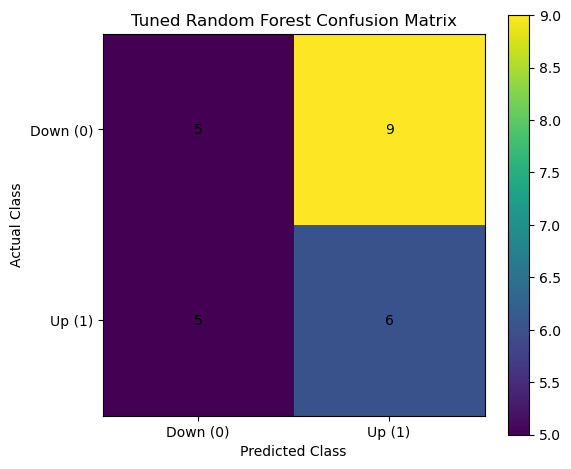

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(tuned_rf_cm)

plt.title(
    'Tuned Random Forest Confusion Matrix'
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.xticks(
    [0, 1],
    ['Down (0)', 'Up (1)']
)

plt.yticks(
    [0, 1],
    ['Down (0)', 'Up (1)']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            tuned_rf_cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()

plt.tight_layout()
plt.savefig(
    "plots/tunedRandomForestConfusionMatrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.show()

In [95]:
## 11. Random Forest Feature Importance

In [96]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols
).sort_values(
    ascending=False
)

print(feature_importance)

movement_lag1      0.182939
sentiment_ma7      0.174181
high_low_spread    0.150965
sentiment_std3     0.140246
sentiment_ma3      0.113807
movement_lag2      0.110487
sentiment_score    0.082579
volume_change      0.044796
dtype: float64


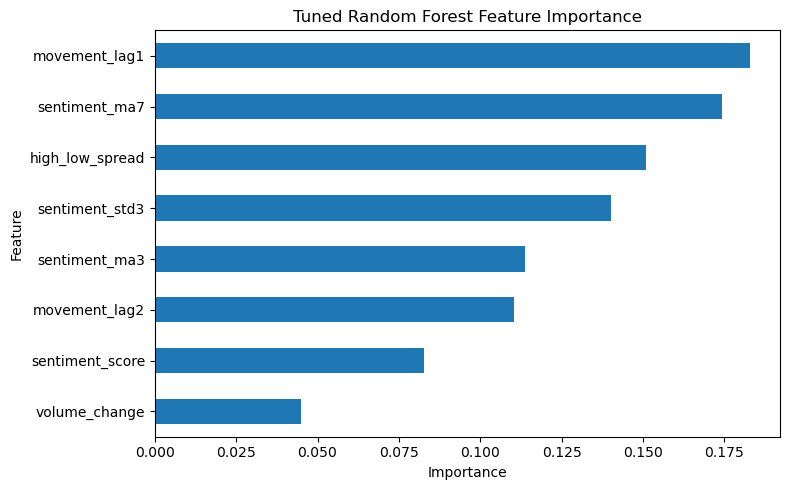

In [97]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind='barh'
)

plt.title(
    'Tuned Random Forest Feature Importance'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig(
    "plots/tunedRandomForestFeatureImportance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.show()

In [98]:
backtest_df = ml_df.iloc[
    split_idx:
].copy()

backtest_df['prediction'] = tuned_rf_pred

print(
    backtest_df[
        [
            'date',
            'close',
            'next_day_target',
            'prediction'
        ]
    ].head()
)

          date     close  next_day_target  prediction
100 2025-07-16  25212.05                0           0
101 2025-07-17  25111.45                0           1
102 2025-07-18  24968.40                1           1
103 2025-07-21  25090.70                0           1
104 2025-07-22  25060.90                1           0


In [99]:
backtest_df['next_day_close'] = (
    backtest_df['close'].shift(-1)
)

backtest_df['market_return'] = (
    backtest_df['next_day_close']
    / backtest_df['close']
) - 1

backtest_df['strategy_return'] = (
    backtest_df['prediction']
    * backtest_df['market_return']
)

backtest_df = backtest_df.dropna().reset_index(
    drop=True
)

In [100]:
backtest_df['buy_hold_growth'] = (
    1 + backtest_df['market_return']
).cumprod()

backtest_df['strategy_growth'] = (
    1 + backtest_df['strategy_return']
).cumprod()

In [101]:
buy_hold_return = (
    backtest_df['buy_hold_growth'].iloc[-1] - 1
)

strategy_return = (
    backtest_df['strategy_growth'].iloc[-1] - 1
)

print(
    "Buy-and-Hold Return:",
    round(buy_hold_return * 100, 2),
    "%"
)

print(
    "Model Strategy Return:",
    round(strategy_return * 100, 2),
    "%"
)

Buy-and-Hold Return: -0.64 %
Model Strategy Return: -0.77 %


In [102]:
## 12. Backtest — Model Strategy vs Buy-and-Hold

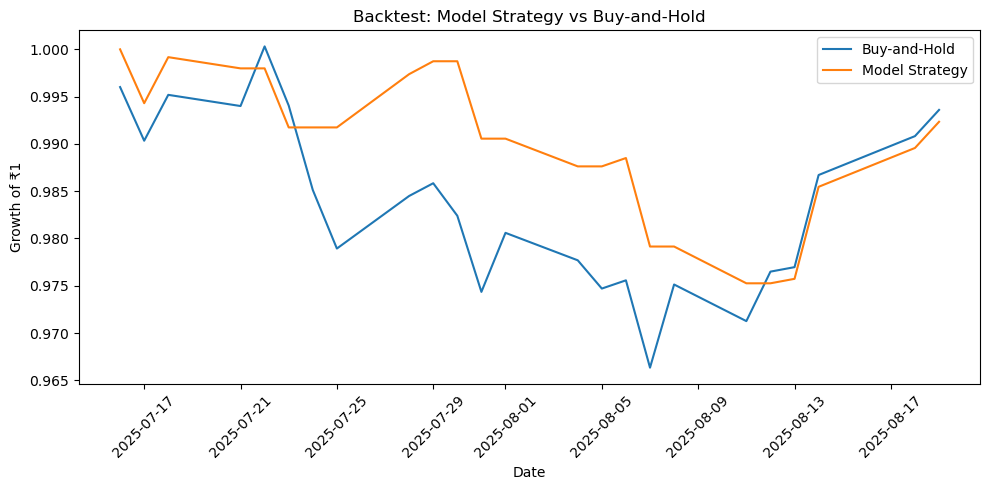

In [103]:
plt.figure(figsize=(10, 5))

plt.plot(
    backtest_df['date'],
    backtest_df['buy_hold_growth'],
    label='Buy-and-Hold'
)

plt.plot(
    backtest_df['date'],
    backtest_df['strategy_growth'],
    label='Model Strategy'
)

plt.title(
    'Backtest: Model Strategy vs Buy-and-Hold'
)

plt.xlabel('Date')
plt.ylabel('Growth of ₹1')

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "plots/backtest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.show()